In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("AusApparalSales4thQrt2020.csv")
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


Task 1

In [24]:
#task 1-a
print(df.isna().sum())

Date       0
Time       0
State      0
Group      0
Unit       0
Sales      0
Week       0
Month      0
Quarter    0
dtype: int64


In [4]:
#task 1-a
print(df.notna().sum())

Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64


In [5]:
#task 1-b
df.dropna(how='all', inplace = True)
df["Sales"] = df["Sales"].fillna(df["Sales"].mean())

In [6]:
#task 1-c

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Sales', 'Unit']] = scaler.fit_transform(df[['Sales', 'Unit']])
df

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,0.015873,0.015873
...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,0.190476,0.190476
7556,30-Dec-2020,Evening,TAS,Kids,0.206349,0.206349
7557,30-Dec-2020,Evening,TAS,Men,0.206349,0.206349
7558,30-Dec-2020,Evening,TAS,Women,0.142857,0.142857


In [7]:
#task 1-d

State_Sales = df.groupby("State")["Sales"].sum().reset_index()
print(State_Sales)

  State       Sales
0   NSW  441.714286
1    NT  109.079365
2   QLD  177.888889
3    SA  339.412698
4   TAS  110.222222
5   VIC  635.968254
6    WA  106.365079


In [8]:
print(State_Sales.sort_values(by="Sales", ascending=False))

  State       Sales
5   VIC  635.968254
0   NSW  441.714286
3    SA  339.412698
2   QLD  177.888889
4   TAS  110.222222
1    NT  109.079365
6    WA  106.365079


In [9]:
#task2

In [10]:
print(df[['Sales','Unit']].describe())

             Sales         Unit
count  7560.000000  7560.000000
mean      0.254054     0.254054
std       0.204784     0.204784
min       0.000000     0.000000
25%       0.095238     0.095238
50%       0.190476     0.190476
75%       0.380952     0.380952
max       1.000000     1.000000


In [11]:
print(df[['Sales','Unit']].mode())

      Sales      Unit
0  0.111111  0.111111


In [12]:
#TASK 2-b

top_sales_group = df.groupby("Group")["Sales"].sum().idxmax()

bottom_sales_group = df.groupby("Group")["Sales"].sum().idxmin()

print(top_sales_group)
print(bottom_sales_group)
                

 Men
 Seniors


In [13]:
#Task 2-D
df['Date']= pd.to_datetime(df['Date'])

#extract week number
df['Week']= df['Date'].dt.isocalendar().week

#extract the month number
df['Month']= df['Date'].dt.month

#extract the quater number
df['Quarter']= df['Date'].dt.quarter

In [14]:
#Weekly Sales 
weekly_sales =df.groupby("Week")["Sales"].sum().reset_index()
print(weekly_sales)

    Week       Sales
0     40   84.857143
1     41  152.777778
2     42  150.476190
3     43  151.587302
4     44  122.460317
5     45  113.809524
6     46  115.761905
7     47  115.380952
8     48  117.698413
9     49  169.412698
10    50  181.492063
11    51  182.317460
12    52  183.047619
13    53   79.571429


In [15]:
Monthly_sales =df.groupby("Month")["Sales"].sum().reset_index()
print(Monthly_sales)

   Month       Sales
0     10  645.650794
1     11  495.761905
2     12  779.238095


In [16]:
Quaterly_sales =df.groupby("Quarter")["Sales"].sum().reset_index()
print(Quaterly_sales)

   Quarter        Sales
0        4  1920.650794


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid")

%matplotlib inline

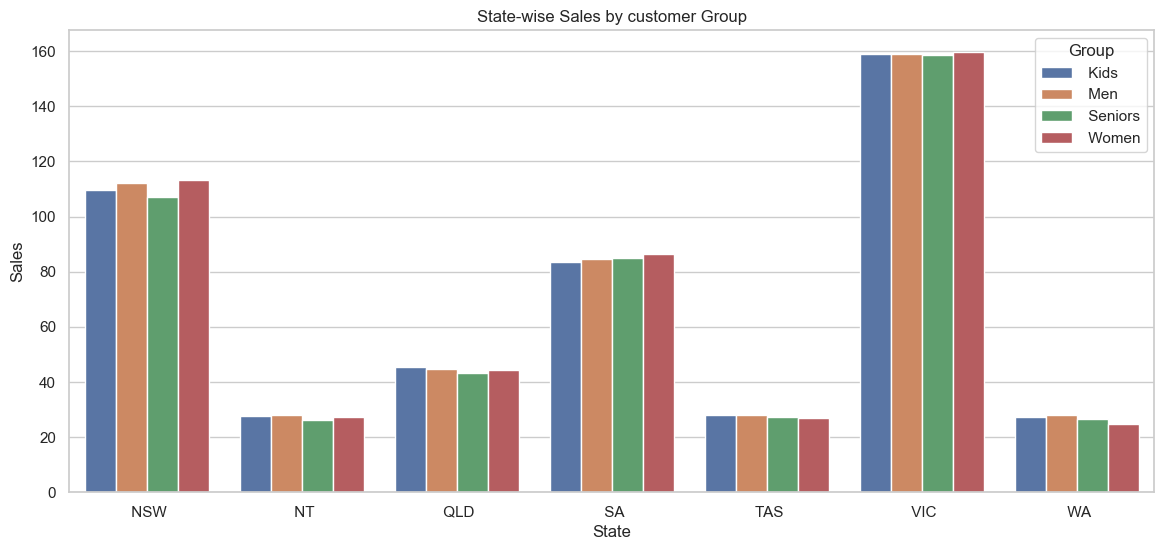

In [18]:
#taks 3-a -1

state_group_sales = df.groupby(['State','Group'])['Sales'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data=state_group_sales , x='State', y='Sales', hue='Group')

plt.title("State-wise Sales by customer Group")
plt.show()

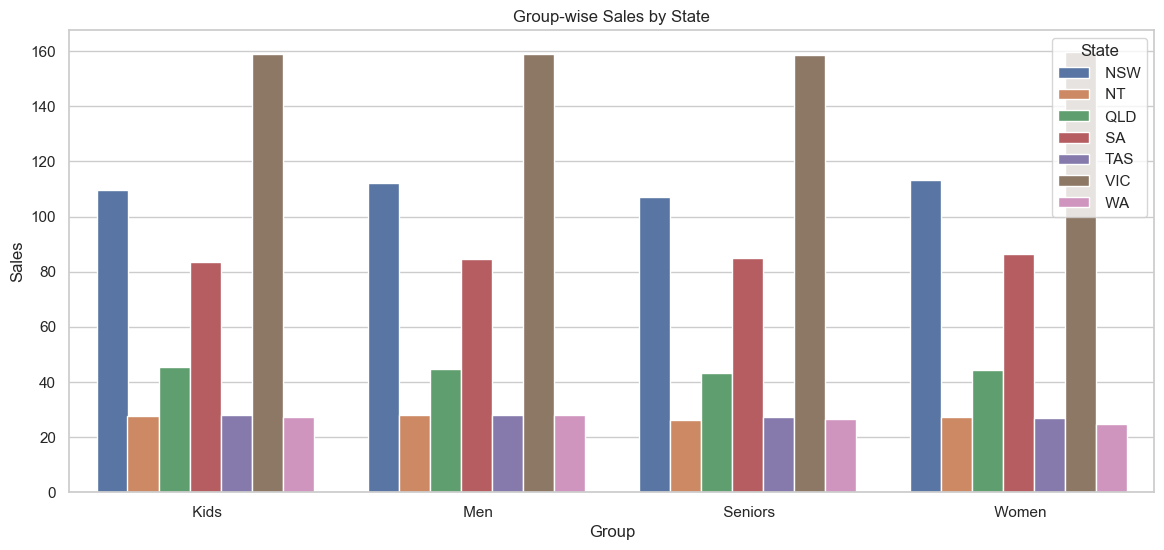

In [19]:
#takse 3-a-2

group_state_sales = df.groupby(['Group','State'])['Sales'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.barplot(data=state_group_sales , x='Group', y='Sales', hue='State')

plt.title("Group-wise Sales by State")
plt.show()

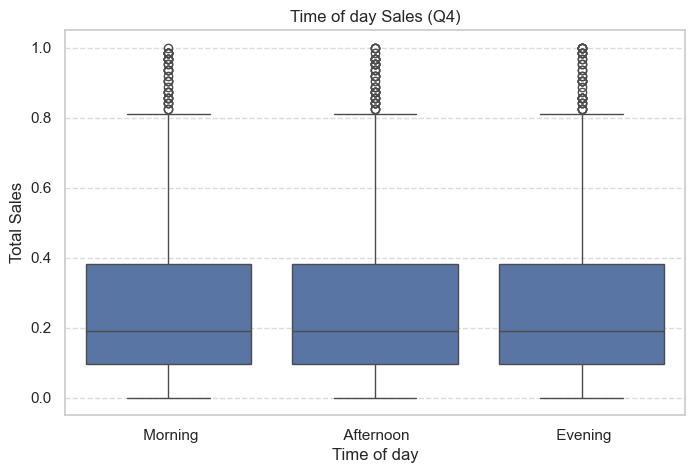

In [20]:
#task3 a-3
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Time", y="Sales")

plt.title("Time of day Sales (Q4)")
plt.xlabel("Time of day")
plt.ylabel("Total Sales")

plt.grid(axis='y' ,linestyle="--", alpha=0.7)

plt.show()

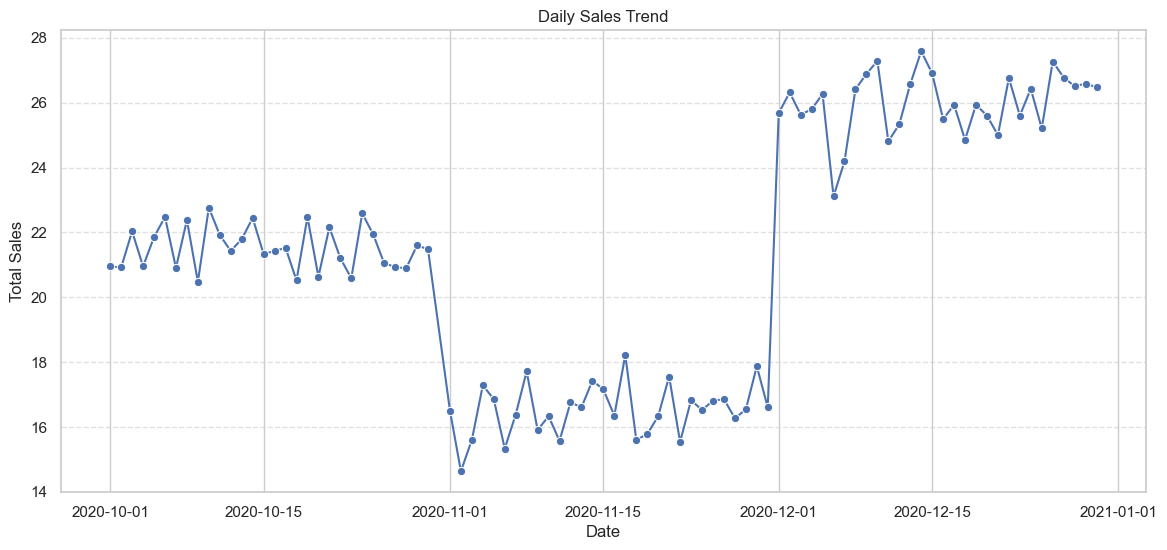

In [21]:
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14,6))
sns.lineplot(data = daily_sales, x='Date', y='Sales', marker='o')

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

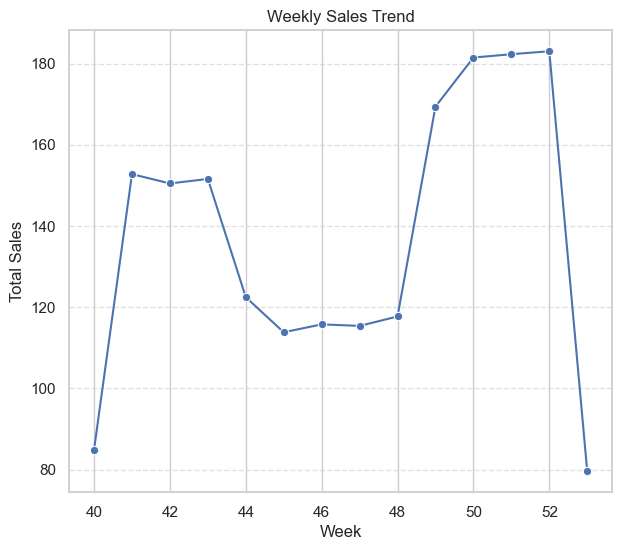

In [22]:
weekly_sales = df.groupby('Week')['Sales'].sum().reset_index()

plt.figure(figsize=(7,6))

sns.lineplot(data = weekly_sales, x='Week', y='Sales', marker='o')

plt.title("Weekly Sales Trend")

plt.xlabel("Week")

plt.ylabel("Total Sales")

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()